# Baseline NLP Yelp Sentiment Analysis

# Importing neccessary libraries

__Data Manipulation__:
- `pandas` and `numpy` libraries for efficient dataset manipulation and numerical operations.
- `Counter` class from the Python's `collections` module for word frequency counts extraction.

__Visualization & Plotting__:
- `matplotlib` library for plotting data distributions and graph visualizations (e.g., bar charts, histograms).
- `wordcloud` for generating Word Clouds consisting of most frequently occuring words across 1-star and 5-star review texts.

__Text Preprocessing__:
- Importing Python's `re` module for working with regular expressions to clean and pre-process text (i.e., removing punctuation, special characters, and extra whitespaces).
- `nltk` library for stopword removal and tokenization of the review texts.
- `stopwords`: importing a pre-defined list of stopwords from the Natural Language Toolkit (NLTK) library.
- `word_tokenize` function form the Natural Language Toolkit (NLTK) library for splitting the review texts into individual words (tokens).

__TF-IDF__:
- Importing the `TfidfVectorizer` class from the scikit-learn library for computing TF-IDF scores to determine the importance of terms in the review texts.


In [76]:
# Data manipulation
import pandas as pd
import numpy as np
from collections import Counter

# Visualization & Plotting
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Text Preprocessing
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('stopwords')

# TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/yevheniiakysel/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/yevheniiakysel/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Loading the Data

In this section, the raw Yelp review data from Kaggle is loaded into a Pandas DataFrame using the built-in `.read_json()` method. This method reads JSON data and converts it into Pandas format.

__Parameters__:
- The path to a JSON file (`yelp_academic_dataset_review.json`).
- `lines=True`: Indicates that the file is in JSON Lines format and ensures each line of the JSON file is read as a separate record (one Yelp review per line).
- `nrows=100000`: Loads only the first 100,000 reviews, which is sufficient for analysis and data exploration. Limiting the dataset size is crucial for resource management and reducing computational overhead.

__Filtering the DataFrame Columns__:
- `reviews_df[['stars', 'text']]`: Selecting only the `'stars'` and `'text'` columns of the DataFrame and reassigning them to the same `reviews_df` variable. This overwrites the DataFrame so it contains only the relevant data for this project.

In [77]:
# Load the review data
reviews_df = pd.read_json('../data/raw/yelp_academic_dataset_review.json', lines=True, nrows=100000)
reviews_df = reviews_df[['stars', 'text']]

### Dataset Cleaning

__Removing Duplicates__
- Removing duplicates from the DataFrame using the Pandas `.drop_duplicates()` method. Since no `subset` parameter is provided, it removes duplicates from all columns in the dataFrame, keeping the first occurence by default. The `inplace=True` parameter modifies the original DataFrame directly instead of returning a new one.

__Removing Missing Values__:
- Removing missing values (NaNs) from the `'text'` column of the DataFrame using the Pandas `.dropna()` method. The `subset=['text']` parameter limits the operation to the specified `'text'` column. The cleaned DataFrame is reassigned back to the `reviews_df` variable.

__Cleaning Whitespaces & Removing Empty Strings__:
- `reviews_df['text']`: Selects the `'text'` column of the DataFrame.
- `.str.strip()`: Removes all leading and trailing whitespaces from a string (e.g., spaces, tabs, newline characters).
- `!= ''`: A boolean indexing technique in Pandas, allows for filtering the DataFrame based on a condidion. Here, it iterates through each review text and ensures that it is **not an empty string** after removing excess whitespaces.
- `reviews_df[...]`: Filters the DataFrame to keep only those rows where the boolean condition is True.

In [78]:
reviews_df.drop_duplicates(inplace=True)
reviews_df = reviews_df.dropna(subset=['text'])
reviews_df = reviews_df[reviews_df['text'].str.strip() != '']

### Exploratory Data Analysis

__Checking the Distribution of Star Ratings__:
Extracting the counts of each unique value in the `'stars'` column and sorting the star ratings in ascending order.
- `reviews_df['stars']`: Selects the `'stars'` column of the DataFrame. 
- `.value_counts()`: Extracts the frequency counts of each unique value (in this case, each star rating).
- `.sort_index()`: Sorts the value frequency counts by star rating (index) in ascending order (default).

__Displaying Basic Information__:
Viewing the basic information about the DataFrame with a built-in `.info()` function, which provides an overview of the dataset structure and properties, such as the number of columns, column labels, data types, memory usage, etc.

__Displaying Texts & Their Ratings__:
Printing the first 10 rows of the DataFrame using the `.head(10)` method, displaying the first ten review texts and their corresponding star ratings.

In [79]:
# Display the frequency of star ratings
star_counts = reviews_df['stars'].value_counts().sort_index()
print(f"Frequency of star ratings: {star_counts}\n")

# Display the basic information about the dataset
print(reviews_df.info())

# Display the first few review texts and their corresponding star ratings
print(f"\nFirst 10 review texts & their corresponding ratings:\n{reviews_df.head(10)}\n") 

Frequency of star ratings: stars
1    10915
2     7987
3    11361
4    25329
5    44374
Name: count, dtype: int64

<class 'pandas.DataFrame'>
Index: 99966 entries, 0 to 99999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   stars   99966 non-null  int64
 1   text    99966 non-null  str  
dtypes: int64(1), str(1)
memory usage: 54.6 MB
None

First 10 review texts & their corresponding ratings:
   stars                                               text
0      3  If you decide to eat here, just be aware it is...
1      5  I've taken a lot of spin classes over the year...
2      3  Family diner. Had the buffet. Eclectic assortm...
3      5  Wow!  Yummy, different,  delicious.   Our favo...
4      4  Cute interior and owner (?) gave us tour of up...
5      1  I am a long term frequent customer of this est...
6      5  Loved this tour! I grabbed a groupon and the p...
7      5  Amazingly amazing wings and homemade bleu chee...
8      

### Plotting the Star Ratings Distrubution



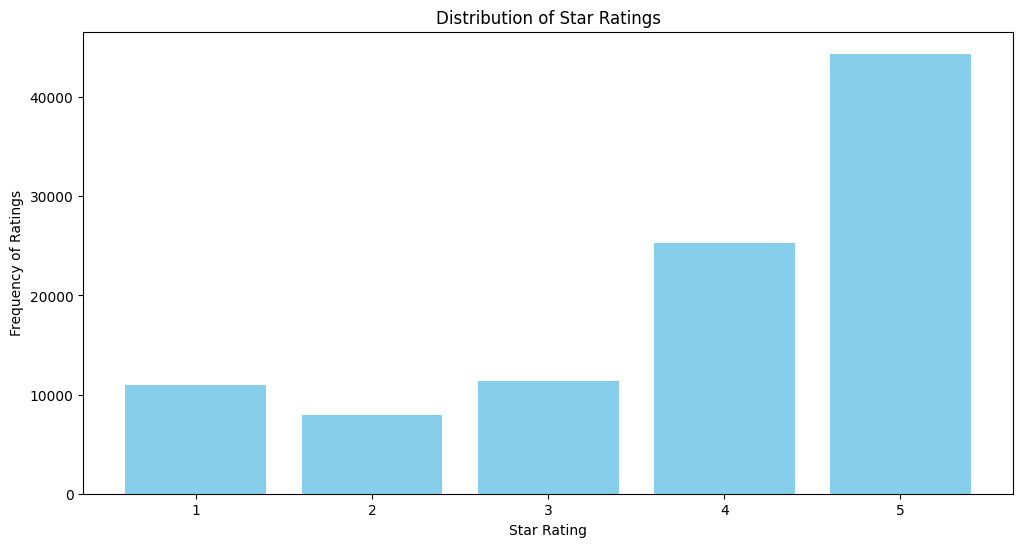

In [80]:
# Plot the distribution of reviews per star rating 
plt.figure(figsize=(12, 6))

plt.bar(star_counts.index, star_counts.values, color='skyblue')
plt.xlabel('Star Rating')
plt.ylabel('Frequency of Ratings')
plt.title('Distribution of Star Ratings')
plt.show()

## Data Preprocessing

This section focuses on preprocessing the textual data, including lowercasing, tokenization, removing punctuation, stopwords, and html artifacts.

__Loading Stopwords__:
- `stopwords.words('english')`: Returns a list of common English stopwords (e.g., "are", "is", "in", etc.).
- `set()`: Converts the stopwords list to a set for faster lookup during preprocessing. This ensures that only unique stopwords are stored, avoiding duplicates.
- `stopwords_set`: A variable containing the loaded English stopword set.

__Removing Negation Terms__:
- Removing "no" and "not" from the stopwords list to preserve negation in sentiment analysis, as they can significantly change the meaning of a review (e.g., "not good" vs "good"). 
- This is done using the `.discard()` method on the `stopwords_set`.

In [81]:
stopwords_set = set(stopwords.words('english'))

stopwords_set.discard('no')
stopwords_set.discard('not')

### Text Preprocessing Function

Defining a preprocessing function to clean the review texts. It takes one argument `'text'`, which represents each review in the the review texts column of the DataFrame.

__Verify Input Format__:
- `isinstance()`: Checks whether the input object/variable is an instance of a specified class. In this case, it takes two parameters:
    - `text`: The input to check.
    - `str`: the class.
- `if not`: A condition that triggers the return statement if the input is not a string.
- `return ""`: Replacing NaNs and other invalid values with an empty string to prevent errors during processing.

__Function Body__:
- `text.lower()`: Converts the text to lowercase.
- `re.sub()`: A method from the re module, used to substitute RegEx pattern matches in a string with a new substring.
    - `(r"<.*?>", "", text)`: Removes HTML tags by replacing any matches of the `<.*?>` pattern in the `text` with an empty string `""`.
    - `(r"[^a-zA-Z\s]", "", text)`: Removes special characters.
    - `(r"\d+", "", text)`: Removes numbers.
- `word_tokenize(text)`: Tokenizes the text into separate words using the `word_tokenize` function from NLTK. The resulting tokens are stored in the `tokens` variable.
- `[word for word in tokens if word not in stopwords_set]`: Removing stopwords from the text using a list comprehension. It iterates over all tokens and keeps only the words that are not present in the earlier defined `stopwords_set`. This results in a list of tokens with all stopwords removed.

__Function Output__:
- `" ".join(tokens)`: Joins the tokens back into a single string separated by whitespace.
- `cleaned_text`: A variable storing the cleaned review texts.

In [82]:
def preprocess_text(text):

    # Ensure the input is a string
    if not isinstance(text, str):
        return ""
    
    text = text.lower()
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\d+", "", text)
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stopwords_set]

    cleaned_text = " ".join(tokens)
    return cleaned_text

__Applying the Function to the Review Texts__:
- Applying the `preprocess_text` function to the `'text'` column of the `reviews_df` DataFrame using the pandas `.apply()` method.
- `reviews_df['cleaned_text']`: Creates a new column storing the preprocessed review texts.

In [83]:
reviews_df['cleaned_text'] = reviews_df['text'].apply(preprocess_text)

### Saving the Dataset

Saving the cleaned and pre-processed `reviews_df` DataFrame to CSV (comma-separated values) for future reuse.
- `.to_csv()`: Converts and saves the Pandas DataFrame in CSV format.
- `index=False`: Exports the DataFrame without the row labels (indexes).

In [84]:
reviews_df.to_csv('../data/processed/yelp_reviews_cleaned.csv', index=False)

### Dataset Filtering

- In this section, the `reviews_df` DataFrame is filtered using boolean indexing to create two subsets containing only the one-star and five-star reviews respectively.
- The `'cleaned_text'` column from each subset is then assigned to its corresponding variable (`one_star_reviews_cleaned` and `five_star_reviews_cleaned`).

In [85]:
# Filter the dataset to create a subset of reviews with only 1-star ratings
one_star_reviews = reviews_df[reviews_df['stars'] == 1]

# Analogously, create a subset of reviews with only 5-star ratings
five_star_reviews = reviews_df[reviews_df['stars'] == 5]

one_star_reviews_cleaned = one_star_reviews['cleaned_text']
five_star_reviews_cleaned = five_star_reviews['cleaned_text']

## Extracting Term Frequency Counts

Defining a `get_word_counts` function for splitting texts into word lists and extracting the frequency counts of the terms in the review text corpus. It takes a single `review_text` argument which represents the cleaned texts form both 1-star and 5-star reviews.

__Function Body__:
- `" ".join(review_text)`: Joins all review texts into a single string for easier word frequency counting. The result is stored in the `combined_review_texts` variable.
- `combined_review_texts.split()`: Splits the combined review texts into individual words.
- `Counter(review_word_list)`: Counts the occurences of each word in the `review_word_list`.

__Function Output__:
`return review_word_list, word_counts` returns a tuple of variables:
    - `review_word_list`: A list containing all words from the review texts.
    - `word_counts`: Contains and the frequency counts for each word in the review text corpus.

In [86]:
def get_word_counts(review_text):
    combined_review_texts = " ".join(review_text)
    review_word_list = combined_review_texts.split()
    word_counts = Counter(review_word_list)

    return review_word_list, word_counts

__Applying the `get_word_counts` Function__:
- Unpacking the output of the `get_word_counts` function for both one-star and five-star cleaned review texts into corresponding variables containing word lists and term frequency counts for each sentiment group.

In [87]:
one_star_word_list, one_star_word_counts = get_word_counts(one_star_reviews_cleaned)
five_star_word_list, five_star_word_counts = get_word_counts(five_star_reviews_cleaned)

- Displaying the most frequent 50 words across review texts from both sentiment categories using the `.most_common()` method provided by the `Counter` class.

In [88]:
print(f"Most frequent 50 words in one star reviews: {one_star_word_counts.most_common(50)}")
print(f"Most frequent 50 words in five star reviews: {five_star_word_counts.most_common(50)}")

Most frequent 50 words in one star reviews: [('not', 12260), ('food', 6477), ('no', 5608), ('would', 4985), ('place', 4965), ('one', 4707), ('service', 4609), ('back', 4577), ('get', 4461), ('time', 4380), ('like', 4169), ('us', 4035), ('never', 3671), ('even', 3513), ('go', 3497), ('said', 3388), ('order', 3141), ('told', 3130), ('dont', 3046), ('good', 2959), ('got', 2958), ('didnt', 2876), ('minutes', 2819), ('ordered', 2711), ('asked', 2636), ('came', 2611), ('could', 2607), ('went', 2448), ('people', 2067), ('first', 1953), ('restaurant', 1908), ('ever', 1856), ('took', 1831), ('im', 1822), ('know', 1822), ('bad', 1822), ('another', 1815), ('customer', 1800), ('going', 1787), ('really', 1771), ('experience', 1763), ('manager', 1752), ('two', 1706), ('table', 1611), ('also', 1598), ('give', 1589), ('called', 1581), ('take', 1571), ('still', 1571), ('come', 1552)]
Most frequent 50 words in five star reviews: [('great', 25432), ('place', 20812), ('food', 19831), ('good', 16203), ('no

__Converting the Cleaned Texts into Lists__:
- Converting the cleaned review texts into Python lists using the pandas `.tolist()` method.
- This prepares the text data for input into the TF-IDF Vectorizer, which expects an iterable of documents.

__Merging Texts__:
- Combining the one-star and five-star review texts into a single list using concatenation.
- The merged lists are stored in the `all_texts` variable.

In [89]:
one_star_texts = one_star_reviews_cleaned.tolist()
five_star_texts = five_star_reviews_cleaned.tolist()

all_texts = one_star_texts + five_star_texts

### Defining Domain Stopwords List
- Examining the 50 most common words extracted from both 1-star and 5-star review texts to identify domain-specific stopwords that are not present in the previously defined `stopwords_set`, but appear frequently without carrying substantial meaning.
- Storing these additional stopwords in a `domain_stopwords` list for later use with the TF-IDF Vectorizer.

In [90]:
# Define a list of domain specific stopwords
domain_stopwords = ['would', 'place', 'one', 'back', 'get', 'us', 'even', 'go', 'said', 'told', 'got', 'im', 'came', 'could', 'went', 'asked', 'give', 'want', 'say', 'never', 'always', 'also', 'aaa', 'ability', 'ac', 'ive', 'wont']

## Initializing the TF_IDF Vectorizer

Initializing the `TfidfVectorizer` class from the scikit-learn library by creating a `tfidf_vectorizer` object and specifying its parameters.

__Parameters__:
- `max_features=5000`: Limits the vocabulary size by setting the maximum number of features (unique words) to 5000.
- `stop_words=domain_stopwords`: Uses the previously defined domain-specific stopwords list so that these words are ignored during the computation of TF-IDF scores.

__Fitting TF-IDF Vectorizer__:
This step fits the TF-IDF Vectorizer on all textual data and calculates TF-IDF scores for each word using the `.fit_transform()` method. It consists of two processes — fitting (learning the vocabulary from the data) and transforming (converting text into numerical vectors). The result is a TF-IDF matrix representing the importance of words across all documents.
- `.fit_transform()`: Analyzes `all_texts`, builds a vocabulary of up to 5000 unique features (words), transforms each document into a numerical vector, and computes TF-IDF scores for each word.
- `.vocabulary_`: Displays a dictionary representation of the learned vocabulary after fitting. It consists of 5000 unique words (features) along with their indicies ranging from 0-4999.
- `.get_feature_names_out()`: Retrieves the list of features (unique words) that the TF-IDF Vectorizer learned during fitting, ordered according to their column indices in the resulting TF-IDF matrix.

In [91]:
tfidf_vectorizer = TfidfVectorizer(max_features=5000, stop_words=domain_stopwords)

# Fit TF-IDF on all data
tfidf_matrix = tfidf_vectorizer.fit_transform(all_texts)

# Display the learned vocabulary after fitting
print(f"The dictionary representation of the learned vocabulary: {tfidf_vectorizer.vocabulary_}\n")

# Extract the feature (word) names
tfidf_words = tfidf_vectorizer.get_feature_names_out()
print(f"First 20 learned features:\n{tfidf_words[:20]}\n")

The dictionary representation of the learned vocabulary: {'long': np.int64(2573), 'term': np.int64(4428), 'frequent': np.int64(1779), 'customer': np.int64(1132), 'establishment': np.int64(1494), 'order': np.int64(3026), 'take': np.int64(4360), 'apps': np.int64(194), 'theyre': np.int64(4458), 'busy': np.int64(612), 'really': np.int64(3514), 'maybe': np.int64(2699), 'half': np.int64(1990), 'full': np.int64(1813), 'best': np.int64(405), 'reach': np.int64(3504), 'ass': np.int64(238), 'yes': np.int64(4979), 'great': np.int64(1930), 'glad': np.int64(1873), 'kanella': np.int64(2374), 'opened': np.int64(3013), 'going': np.int64(1890), 'pay': np.int64(3151), 'everything': np.int64(1514), 'la': np.int64(2422), 'carte': np.int64(695), 'food': np.int64(1738), 'wasnt': np.int64(4829), 'terrible': np.int64(4431), 'not': np.int64(2946), 'impressive': np.int64(2214), 'brought': np.int64(563), 'basket': np.int64(344), 'chips': np.int64(811), 'tomato': np.int64(4521), 'sauce': np.int64(3775), 'politely'

### Matrix Slicing

Splitting the TF-IDF matrix back into 1-star and 5-star review submatrices by index. Since `tfidf_matrix` was created from `all_texts` (a concatenation of one-star and five-star reviews), the original indices are preserved.
- `:len(one_star_texts`: Selects rows starting from the default index 0 and ends at the index `one_star_texts` length. The resulting 1-star submatrix is stored in `tfidf_one_star_matrix`.
- `len(one_star_texts):`: Selects rows starting from the index of `one_star_texts` length, and stops at the last row of the matrix. The resulting 5-star submatrix is stored in `tfidf_five_star_matrix`.


__Summing the TF-IDF Scores__:
This step aggregates TF-IDF scores for each word across all documents in each subset, creating a per-word importance score.
- `.sum(axis=0)`: Sums along the rows and down the columns, so for each word (each column) it adds up its TF-IDF scores across all documents (all rows).
- `np.asarray()`: Converts the input into a NumPy array to ensure standardized format.
- `.flatten()`: Flattens the NumPy array to a 1D array (collapses all dimentions into a one-dimentional array).

In [92]:
tfidf_one_star_matrix = tfidf_matrix[:len(one_star_texts)]
tfidf_five_star_matrix = tfidf_matrix[len(one_star_texts):]

one_star_scores = np.asarray(tfidf_one_star_matrix.sum(axis=0)).flatten()
five_star_scores = np.asarray(tfidf_five_star_matrix.sum(axis=0)).flatten()

### Creating Word-Score Pairs

- `zip()`: Combines items from two or more iterables into tuples. Here, each word from `tfidf_words` is paired with its corresponding score from `one_star_scores` or `five_star_scores`.
- `list()`: Converts the resulting word-score tuples into a list. The resulting lists of word-score pairs are stored in `one_star_word_scores` and `five_star_word_scores`.

__Rounding TF-IDF Scores__:
Rounding the TF-IDF importance scores for each word using the Python's `round()` function inside a list comprehension. It iterates over each tuple in earlier defined 1-star and 5-star lists and returns a list of tuples with rounded scores for readability.
- `for word, score`: Iterates over each word-score pair in the lists (`one_star_word_scores` and `five_star_word_scores`).
- `(word, round(score, 1))`: Creates a new tuple containing the word and its rounded TF-IDF score.

In [93]:
# Zip words and their respective scores into pair tuples
one_star_word_scores = list(zip(tfidf_words, one_star_scores))
five_star_word_scores = list(zip(tfidf_words, five_star_scores))

# Round the scores for readability
one_star_rounded = [(word, round(score, 1)) for word, score in one_star_word_scores]
five_star_rounded = [(word, round(score, 1)) for word, score in five_star_word_scores]

## Extracting the Most Important TF-IDF Words

Defining a `get_top_words` function to retrieve the 50 words with the highest TF-IDF scores from both 1-star and 5-star reviews.

__Parameters__:
- `word_scores`: The list of word-score tuples to be passed into the function (`one_star_rounded` or `five_star_rounded`).
- `n=50`: Sets the default number of retrieved word-score pairs to 50.

__Function Body__:
- `.sort()`: Sorts the list in place according to the criteria specified using the `key` parameter.
    - `key=lambda score: score[1]`: Sorts by the second item in each tuple (the rounded TF-IDF score).
    - `reverse=True`: Reverses the list so that the words with highest scores are displayed first.

__Function Output__:
- `return word_scores[:n]`: Returns a slice of the sorted list from index 0 to n. In this case, n is set to 50 by default.

In [94]:
def get_top_words(word_scores, n=50):
    word_scores.sort(key=lambda score: score[1], reverse=True)
    return word_scores[:n]

top_1star_words = get_top_words(one_star_rounded)
top_5star_words = get_top_words(five_star_rounded)

- Printing the top 50 words with the highest TF-IDF scores for 1-star and 5-star review texts.

In [95]:
print(f"Top 50 1-star TF-IDF words:{top_1star_words}")
print(f"Top 50 5-star TF-IDF words:{top_5star_words}")

Top 50 1-star TF-IDF words:[('not', np.float64(623.7)), ('no', np.float64(376.4)), ('food', np.float64(368.6)), ('service', np.float64(292.4)), ('minutes', np.float64(256.3)), ('time', np.float64(255.3)), ('order', np.float64(252.2)), ('like', np.float64(250.9)), ('dont', np.float64(235.1)), ('didnt', np.float64(217.1)), ('ordered', np.float64(207.2)), ('worst', np.float64(206.7)), ('bad', np.float64(188.5)), ('rude', np.float64(178.2)), ('good', np.float64(175.7)), ('horrible', np.float64(168.3)), ('customer', np.float64(163.0)), ('ever', np.float64(162.2)), ('terrible', np.float64(161.0)), ('took', np.float64(156.0)), ('manager', np.float64(155.9)), ('people', np.float64(154.9)), ('money', np.float64(154.6)), ('going', np.float64(144.4)), ('restaurant', np.float64(144.0)), ('another', np.float64(141.0)), ('called', np.float64(139.4)), ('left', np.float64(135.4)), ('know', np.float64(134.9)), ('pizza', np.float64(132.8)), ('first', np.float64(132.5)), ('table', np.float64(130.6)), ('e

## Computing 

__Defining Sentiment Lexicons__:
- Examining the previously extracted words with the highest TF-IDF importance scores and defining sentiment lexicons based on the retrieved sentiment-driven words for both positive and negative polarities.
- Converting the positive and negative words lists into sets to avoid duplicates.
- The resulting sentiment lexicons, stored in `positive_lexicon` and `negative_lexicon`, will serve as reference points for computing weighted sentiment scores for review texts across all rating categories.

In [96]:
positive_lexicon = set(['delicious', 'friendly', 'nice', 'great', 'awesome', 'excellent', 'favourite', 'wonderful', 'perfect'])
negative_lexicon = set(['worst', 'bad', 'rude','horrible', 'terrible', 'dirty', 'poor', 'dissapointed', 'awful'])

__Creating Filtered Dictionaries__:
- Creating filtered dictionaries from word-score pairs using dictionary comprehensions.
- `{word: score for word, score in ...}`: Iterates over the word-score pairs and stores them as key-value pairs in a dictionary.
- `if word in positive_lexicon / negative_lexicon`: Filters the words by checking whether they are present in the predefined sentiment lexicons.
- `positive_weighted`: Contains words from the 5-star reviews that match the positive lexicon, along with their TF-IDF scores.
- `negative_weighted`: Contains words from the 1-star reviews that match the negative lexicon, along with their TF-IDF scores.

In [ ]:
positive_weighted = {word: score for word, score in top_5star_words if word in positive_lexicon}
negative_weighted = {word: score for word, score in top_1star_words if word in negative_lexicon}

### Defining a Weighted Sentiment Analysis Function

In this code block, a weighted sentiment analysis function is defined to compute sentiment scores for each review across all star rating categories using TF-IDF-based weights.

__Function Body__:
- Splitting the review text into individual words:
    - `review_text.split()`: Splits the cleaned review text into a list of words.
    - `set()`: Wraps the words in a set to remove duplicates to avoid repetition bias (meaning each word is counted only once per review).

- Calculating weighted sentiment scores:
    - `.get(word, 0)`: Retrieves the TF-IDF score (value) of a word (key) from the corresponding dictionary (`positive_weighted` and `negative_weighted`). Returns 0 by default if the score (value) is not found to prevent errors.
    - `for word in words`: Iterates through each unique word in the previously defined set of words.
    - `sum()`: Sums the TF-IDF scores of all matching words to create total positive and negative sentiment scores.

__Function Output__:
- `return positive_scores - negative_scores`: Returns the difference between positive and negative scores, resulting in an overall sentiment score for the review.

In [ ]:
def compute_sentiment(review_text):
    words = set(review_text.split())

    positive_scores = sum([positive_weighted.get(word, 0) for word in words])
    negative_scores = sum([negative_weighted.get(word, 0) for word in words])

    return positive_scores - negative_scores

__Applying the `compute_sentiment` Function to the Review Text__:
- Applying the weighted sentiment analysis function to the `'cleaned_text'` column of the DataFrame to compute a sentiment score for each review.
- `reviews_df["sentiment_score"]`: Stores the computed sentiment scores in a new column of the DataFrame.

In [ ]:
reviews_df["sentiment_score"] = reviews_df["cleaned_text"].apply(compute_sentiment)

In [100]:
avg_sentiment_score = reviews_df.groupby('stars')['sentiment_score'].mean()
distribution = reviews_df.groupby('stars')['sentiment_score'].describe()

print(f"Average sentiment score per star rating: {avg_sentiment_score}\n")
print(f"Distribution: {distribution}\n")


Average sentiment score per star rating: stars
1     203.649208
2     582.880080
3     899.755215
4    1368.840696
5    1382.820746
Name: sentiment_score, dtype: float64

Distribution:          count         mean          std    min    25%     50%     75%     max
stars                                                                         
1      10915.0   203.649208   692.779640 -902.7 -168.3     0.0     0.0  4199.9
2       7987.0   582.880080   933.882551 -714.2    0.0     0.0   894.1  4434.3
3      11361.0   899.755215  1064.102721 -573.4    0.0   693.8  1982.6  5094.0
4      25329.0  1368.840696  1171.006277 -395.2    0.0  1121.3  1982.6  5493.2
5      44374.0  1382.820746  1178.889923 -395.2    0.0  1298.3  2193.0  6358.9



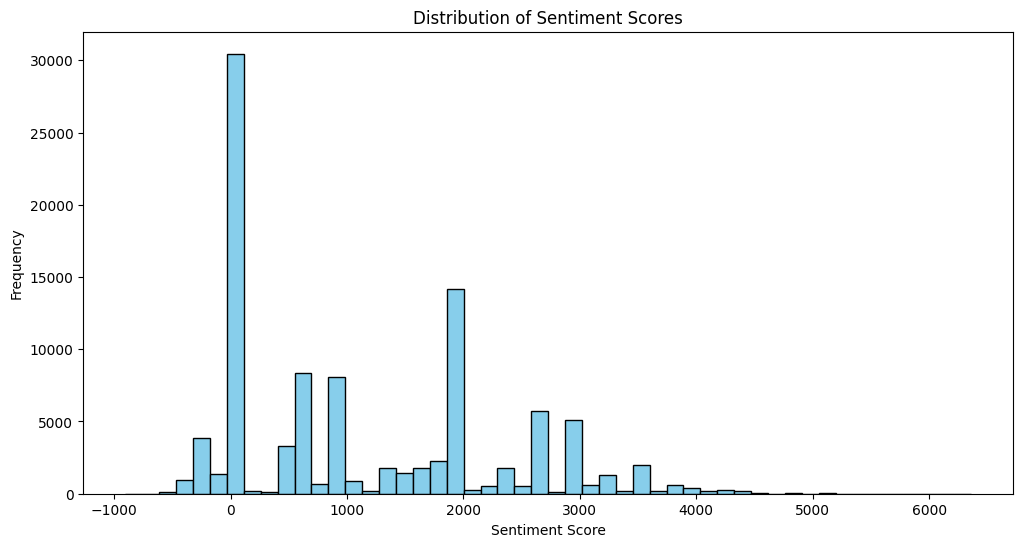

In [101]:
# Plot the general distribution of sentiment scores
plt.figure(figsize=(12,6))

plt.hist(reviews_df['sentiment_score'], bins=50, color='skyblue', edgecolor='black')
plt.xlabel('Sentiment Score')
plt.ylabel('Frequency')
plt.title('Distribution of Sentiment Scores')

plt.show()


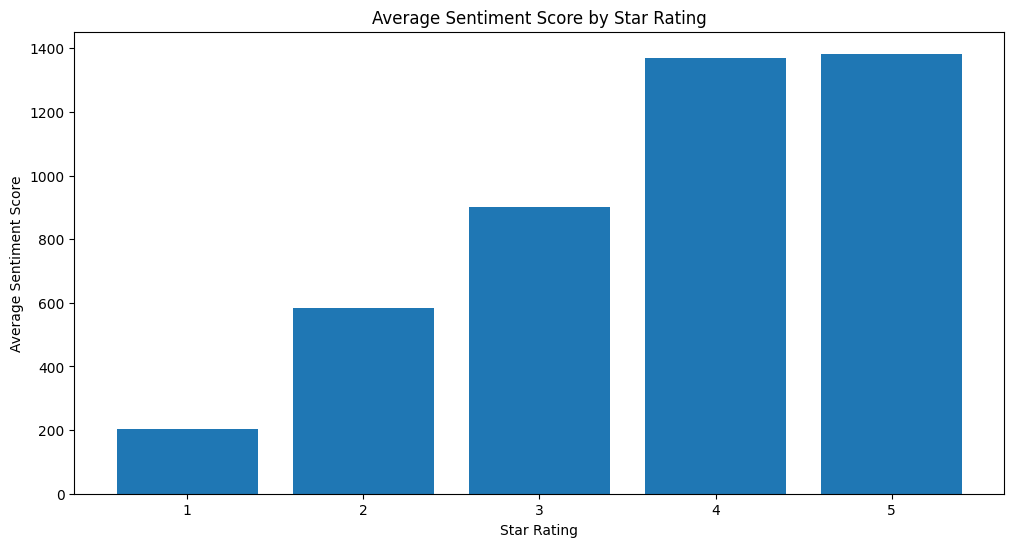

In [102]:
# Plot the average sentiment score by star rating
plt.figure(figsize=(12,6))

plt.bar(avg_sentiment_score.index, avg_sentiment_score.values)
plt.xlabel('Star Rating')
plt.ylabel('Average Sentiment Score')
plt.title('Average Sentiment Score by Star Rating')

plt.show()

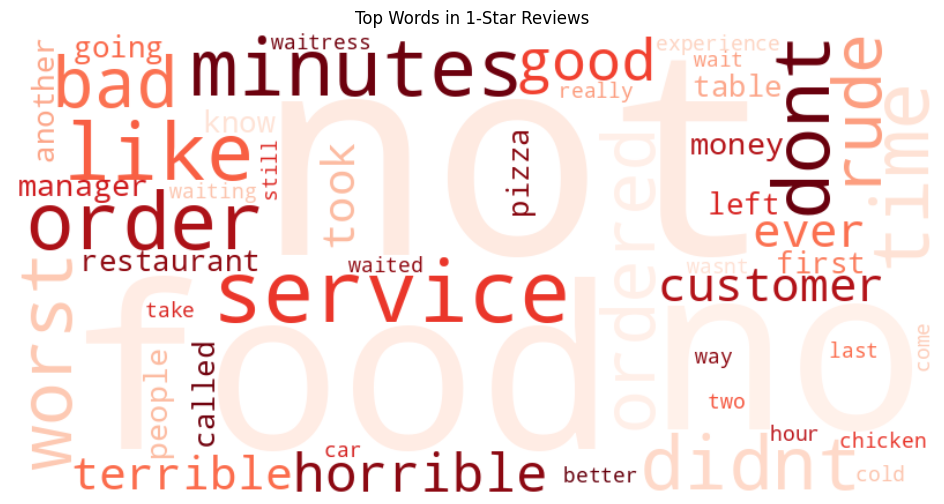

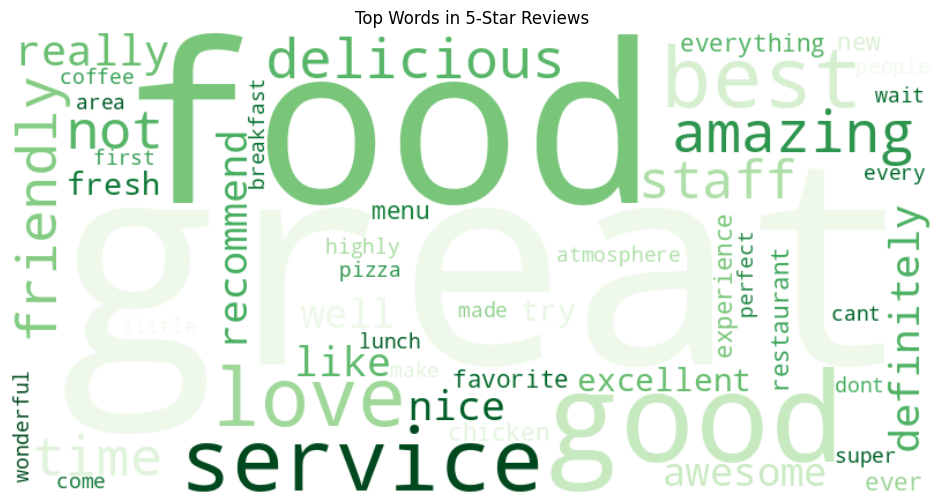

In [103]:
# Create dictionaries containing the top words from the TF-IDF list
one_star_dict = dict(top_1star_words)
five_star_dict = dict(top_5star_words)

# Define a function for plotting a word cloud from a weighted dictionary
def word_cloud_plot(weighted_dict, title, colormap):
    wordcloud = WordCloud(width=800, height=400, background_color='white', colormap=colormap).generate_from_frequencies(weighted_dict)

    plt.figure(figsize=(12,6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)

    plt.show()

word_cloud_plot(one_star_dict, "Top Words in 1-Star Reviews", colormap='Reds')
word_cloud_plot(five_star_dict, "Top Words in 5-Star Reviews", colormap='Greens')